In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

# CREDIT CARD FRAUD DETECTION

In [2]:
data=pd.read_csv('credit_card_fraud_dataset.csv')
data.head(10)

,transaction_id,customer_id,merchant_category,transaction_type,transaction_amount,account_balance,transaction_hour,is_international,device_type,is_fraud,transaction_channel,txn_count_last_24h
0,TXN100000,CUST8270,Grocery,Online,41.99,39494.37,17,0,Mobile,0,Online,1
1,TXN100001,CUST1860,Electronics,Online,68.67,62750.24,15,0,Mobile,0,POS,2
2,TXN100002,CUST6390,Fuel,Online,5195.46,36175.59,21,0,Web,0,ATM,3
3,TXN100003,CUST6191,NaN,POS,252.95,27334.09,0,0,Web,0,Online,4
4,TXN100004,CUST6734,NaN,Online,3092.25,64499.26,15,0,Mobile,0,POS,5
5,TXN100005,CUST7265,Restaurant,POS,3793.55,90235.37,21,0,Mobile,0,ATM,6
6,TXN100006,CUST1466,NaN,POS,1602.74,63318.34,12,0,Web,0,Online,7
7,TXN100007,CUST5426,Grocery,POS,3664.58,47719.11,0,0,Mobile,0,POS,8
8,TXN100008,CUST6578,NaN,POS,224.91,57737.49,20,0,Card,0,ATM,9
9,TXN100009,CUST9322,Grocery,POS,13895.15,26430.69,17,0,Mobile,0,Online,10


### Data Inspection & Cleaning

In [3]:
data.dtypes

transaction_id          object
customer_id             object
merchant_category       object
transaction_type        object
transaction_amount     float64
account_balance        float64
transaction_hour         int64
is_international         int64
device_type             object
is_fraud                 int64
transaction_channel     object
txn_count_last_24h       int64
dtype: object

In [4]:
data.size

360000

In [5]:
data.shape

(30000, 12)

In [6]:
data.info

<bound method DataFrame.info of       transaction_id customer_id merchant_category transaction_type  \
0          TXN100000    CUST8270           Grocery           Online   
1          TXN100001    CUST1860       Electronics           Online   
2          TXN100002    CUST6390              Fuel           Online   
3          TXN100003    CUST6191               NaN              POS   
4          TXN100004    CUST6734               NaN           Online   
...              ...         ...               ...              ...   
29995      TXN129995    CUST3090           Grocery              POS   
29996      TXN129996    CUST9652        Restaurant              POS   
29997      TXN129997    CUST1148       Electronics           Online   
29998      TXN129998    CUST5433              Fuel              POS   
29999      TXN129999    CUST6098              Fuel           Online   

       transaction_amount  account_balance  transaction_hour  \
0                   41.99         39494.37         

In [7]:
data.describe()

,transaction_amount,account_balance,transaction_hour,is_international,is_fraud,txn_count_last_24h
count,30000.000000,29100.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,1994.795218,49846.355910,11.430800,0.080900,0.020933,5.500000
std,1984.957555,19940.841232,6.906302,0.272686,0.143164,2.872329
min,0.460000,-26400.070000,0.000000,0.000000,0.000000,1.000000
25%,572.275000,36368.295000,5.000000,0.000000,0.000000,3.000000
50%,1393.980000,49797.520000,11.000000,0.000000,0.000000,5.500000
75%,2741.615000,63266.340000,17.000000,0.000000,0.000000,8.000000
max,18792.210000,126775.760000,23.000000,1.000000,1.000000,10.000000


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.isna().sum()

transaction_id            0
customer_id               0
merchant_category      2133
transaction_type          0
transaction_amount        0
account_balance         900
transaction_hour          0
is_international          0
device_type            1566
is_fraud                  0
transaction_channel       0
txn_count_last_24h        0
dtype: int64

#### Handling Missing Values

In [10]:
data['merchant_category']=data['merchant_category'].fillna('unknown')
data['device_type']=data['device_type'].fillna('unknown')

In [11]:
mean = data['account_balance'].mean()
data['account_balance']=data['account_balance'].fillna(mean)

In [12]:
data.isna().sum()

transaction_id         0
customer_id            0
merchant_category      0
transaction_type       0
transaction_amount     0
account_balance        0
transaction_hour       0
is_international       0
device_type            0
is_fraud               0
transaction_channel    0
txn_count_last_24h     0
dtype: int64

In [13]:
for i in data.columns:
    print(i,data[i].unique())

transaction_id ['TXN100000' 'TXN100001' 'TXN100002' ... 'TXN129997' 'TXN129998'
 'TXN129999']
customer_id ['CUST8270' 'CUST1860' 'CUST6390' ... 'CUST2090' 'CUST3856' 'CUST5032']
merchant_category ['Grocery' 'Electronics' 'Fuel' 'unknown' 'Restaurant' 'Travel']
transaction_type ['Online' 'POS' 'ATM']
transaction_amount [  41.99   68.67 5195.46 ...  717.19  677.36  730.62]
account_balance [39494.37 62750.24 36175.59 ... 70495.41 54521.38 32443.77]
transaction_hour [17 15 21  0 12 20  8 13 14  9  3 16 18 22  7 19  5 10  4  2  6 23  1 11]
is_international [0 1]
device_type ['Mobile' 'Web' 'Card' 'unknown']
is_fraud [0 1]
transaction_channel ['Online' 'POS' 'ATM']
txn_count_last_24h [ 1  2  3  4  5  6  7  8  9 10]


In [14]:
data.drop(columns=['transaction_id','customer_id'],inplace=True)

In [15]:
data.columns

Index(['merchant_category', 'transaction_type', 'transaction_amount',
       'account_balance', 'transaction_hour', 'is_international',
       'device_type', 'is_fraud', 'transaction_channel', 'txn_count_last_24h'],
      dtype='object')

### Preprocessing

In [16]:
le1= LabelEncoder()
le2= LabelEncoder()
le3= LabelEncoder()
le4= LabelEncoder()
data['merchant_category']=le1.fit_transform(data['merchant_category'])
data['transaction_type']=le2.fit_transform(data['transaction_type'])
data['device_type']=le3.fit_transform(data['device_type'])
data['transaction_channel']=le4.fit_transform(data['transaction_channel'])

In [17]:
data.dtypes

merchant_category        int64
transaction_type         int64
transaction_amount     float64
account_balance        float64
transaction_hour         int64
is_international         int64
device_type              int64
is_fraud                 int64
transaction_channel      int64
txn_count_last_24h       int64
dtype: object

In [18]:
data['is_fraud'].value_counts()

is_fraud
0    29372
1      628
Name: count, dtype: int64

### EDA (Exploratory Data Analysis)

#### Count plot for target

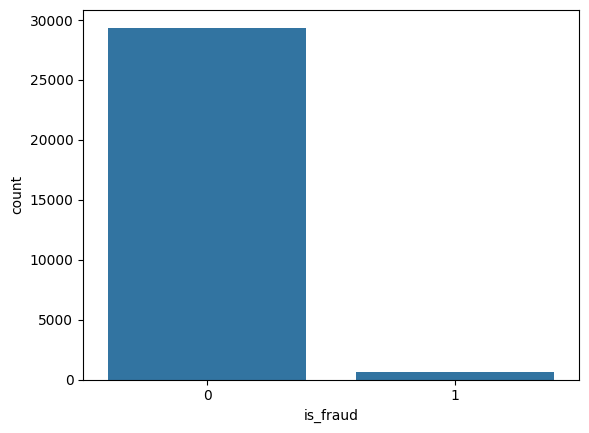

In [19]:
sns.countplot(data=data,x='is_fraud')
plt.show()

#### Feature Distribution using Histogram

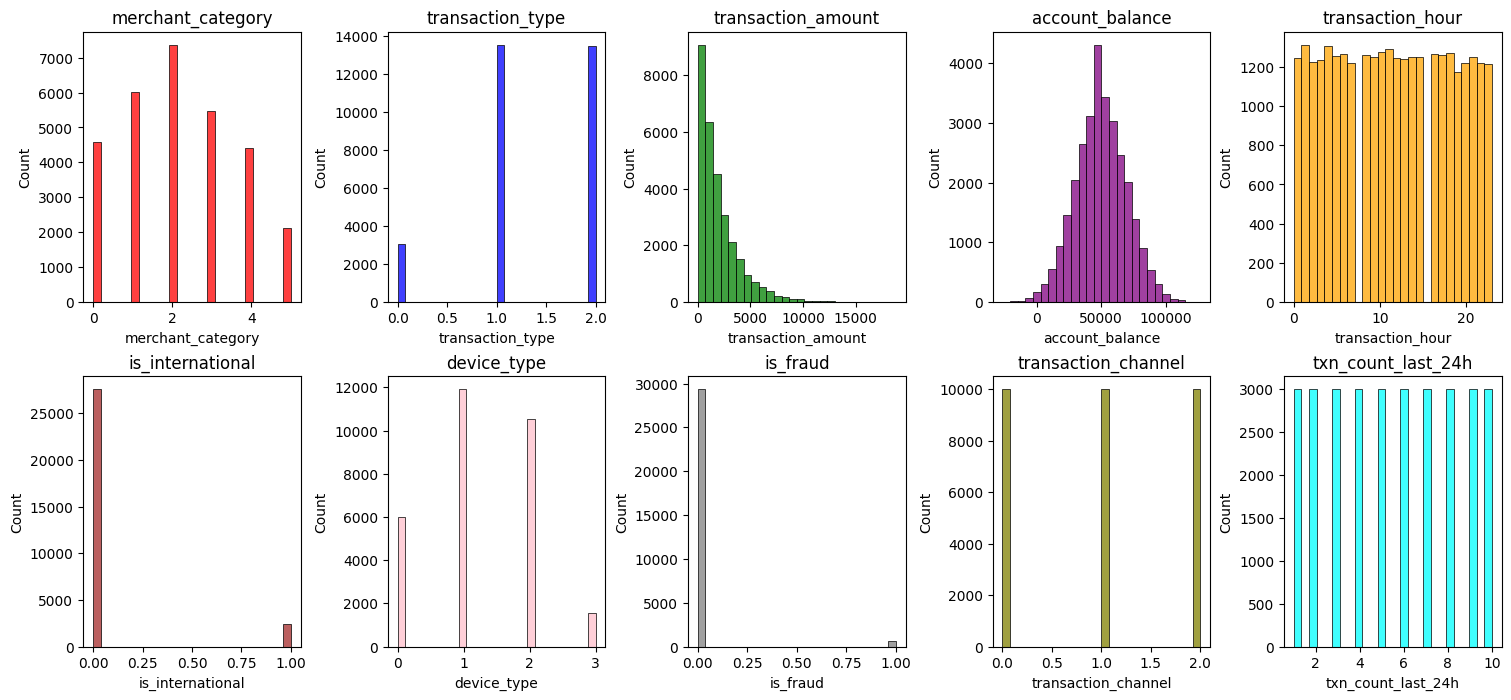

In [20]:
column = ['merchant_category', 'transaction_type', 'transaction_amount',
          'account_balance','transaction_hour', 'is_international',
          'device_type', 'is_fraud','transaction_channel',
          'txn_count_last_24h']

colors = ['red','blue','green','purple','orange',
          'brown','pink','gray','olive','cyan']

plt.figure(figsize=(15,15), layout='constrained')

for i in range(len(column)):
    plt.subplot(5,5,i+1)
    sns.histplot(data[column[i]], bins=26, color=colors[i])
    plt.title(column[i])

plt.show()

#### KDE Plot (Smooth Distribution Curve)

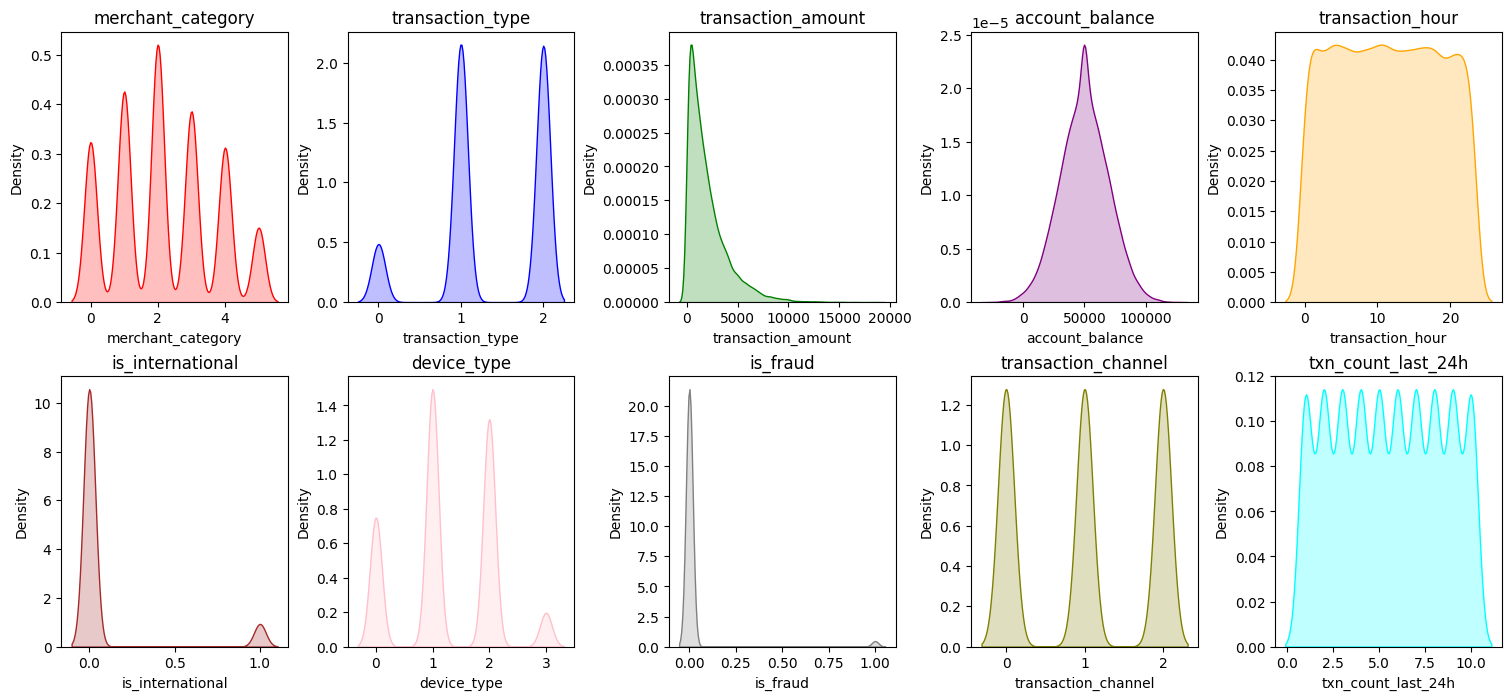

In [21]:
column = ['merchant_category', 'transaction_type', 'transaction_amount','account_balance','transaction_hour', 'is_international','device_type', 'is_fraud',
          'transaction_channel', 'txn_count_last_24h']
colors = ['red','blue','green','purple','orange',
          'brown','pink','gray','olive','cyan']

plt.figure(figsize=(15,15), layout='constrained')

for i in range(len(column)):
    plt.subplot(5,5,i+1)
    sns.kdeplot(data[column[i]], fill=True, color=colors[i])
    plt.title(column[i])

plt.show()

#### Pairwise Feature Relationships

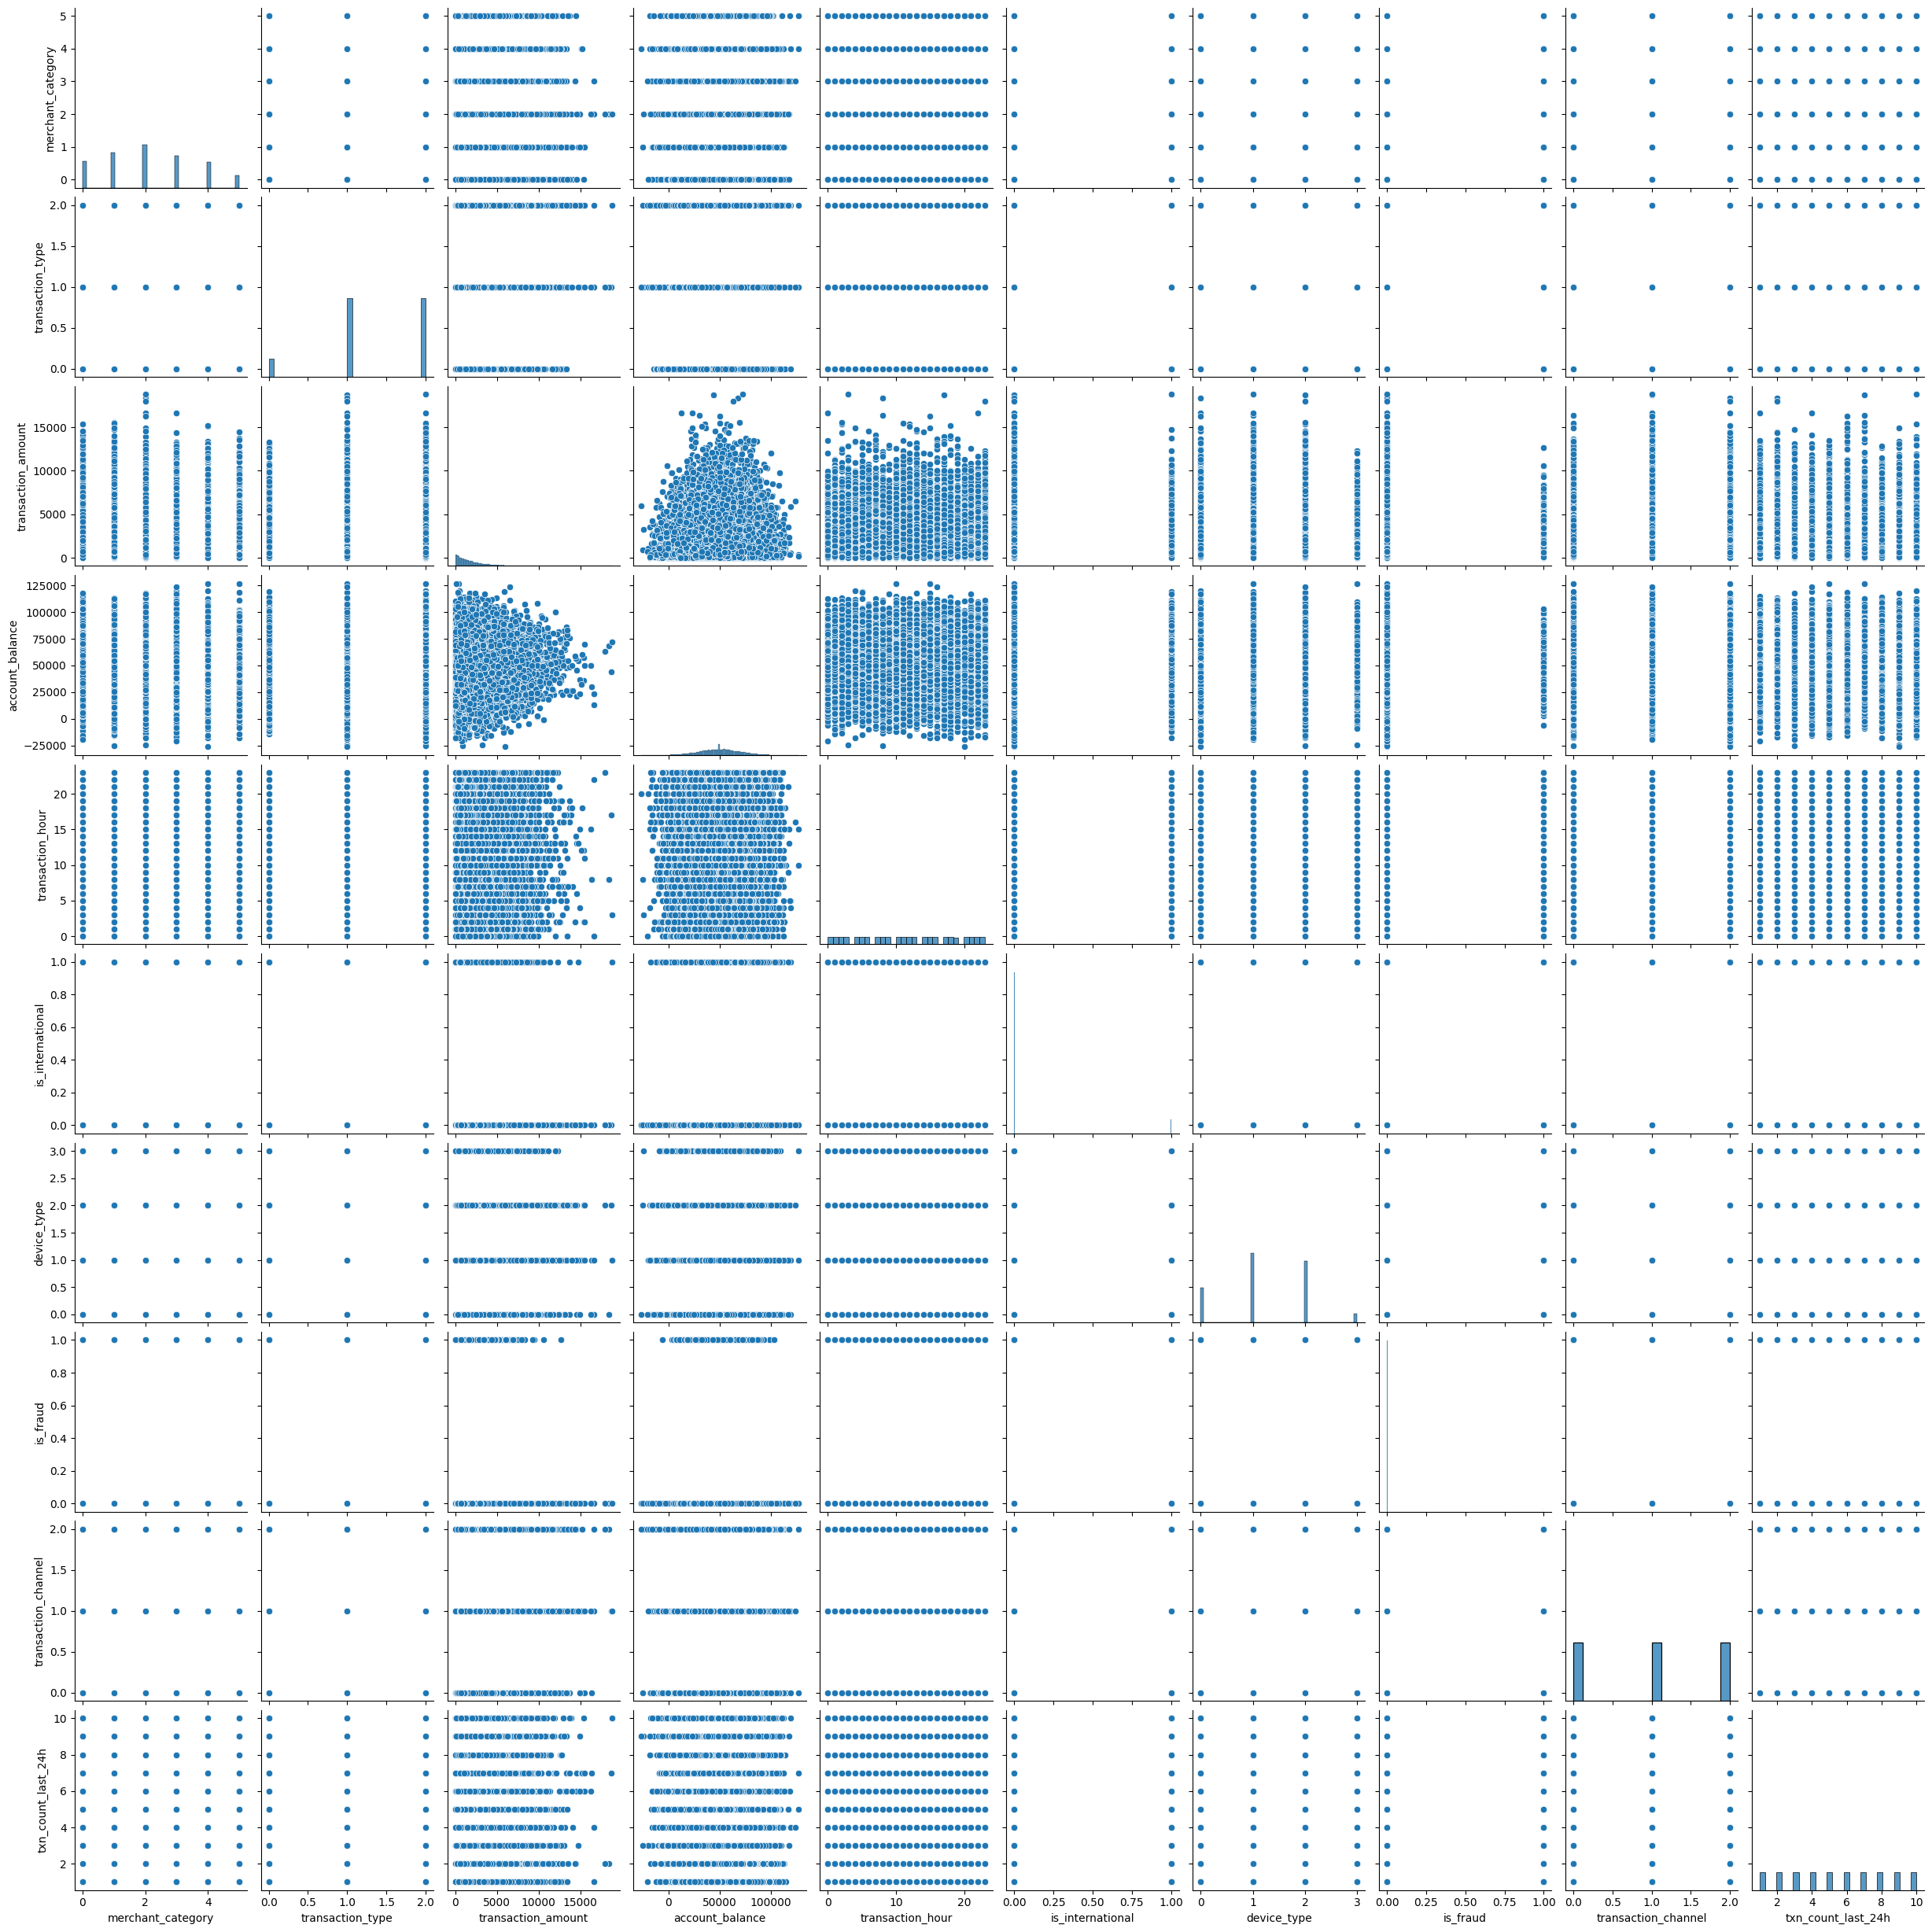

In [22]:
sns.pairplot(data)

#### Boxplots Showing Distribution of Each Feature

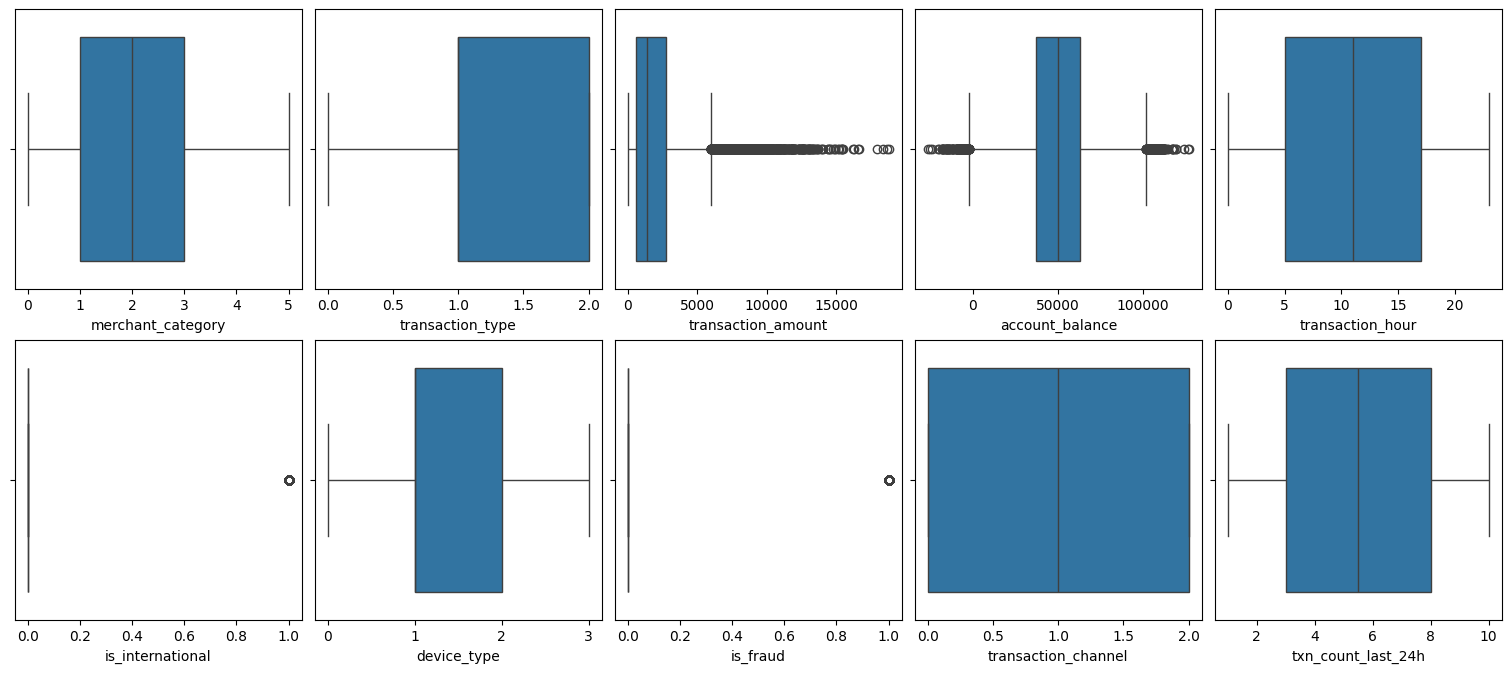

In [23]:
col=['merchant_category', 'transaction_type', 'transaction_amount','account_balance', 'transaction_hour', 'is_international',
          'device_type', 'is_fraud', 'transaction_channel', 'txn_count_last_24h']
plt.figure(figsize=(15,15),layout='constrained')
for i in range(len(col)):
       plt.subplot(5,5,i+1)
       sns.boxplot(data=data,x=col[i])
       plt.savefig('my_graph.png')

#### Outlier Treating Using Capping

In [24]:
outlier = ['transaction_amount','account_balance']
for i in outlier:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3-Q1
    lower_limit=Q1-1.5*IQR   #Values outside this range are capped, not removed.
    upper_limit=Q3+1.5*IQR 
    data[i] = data[i].clip(lower_limit, upper_limit)

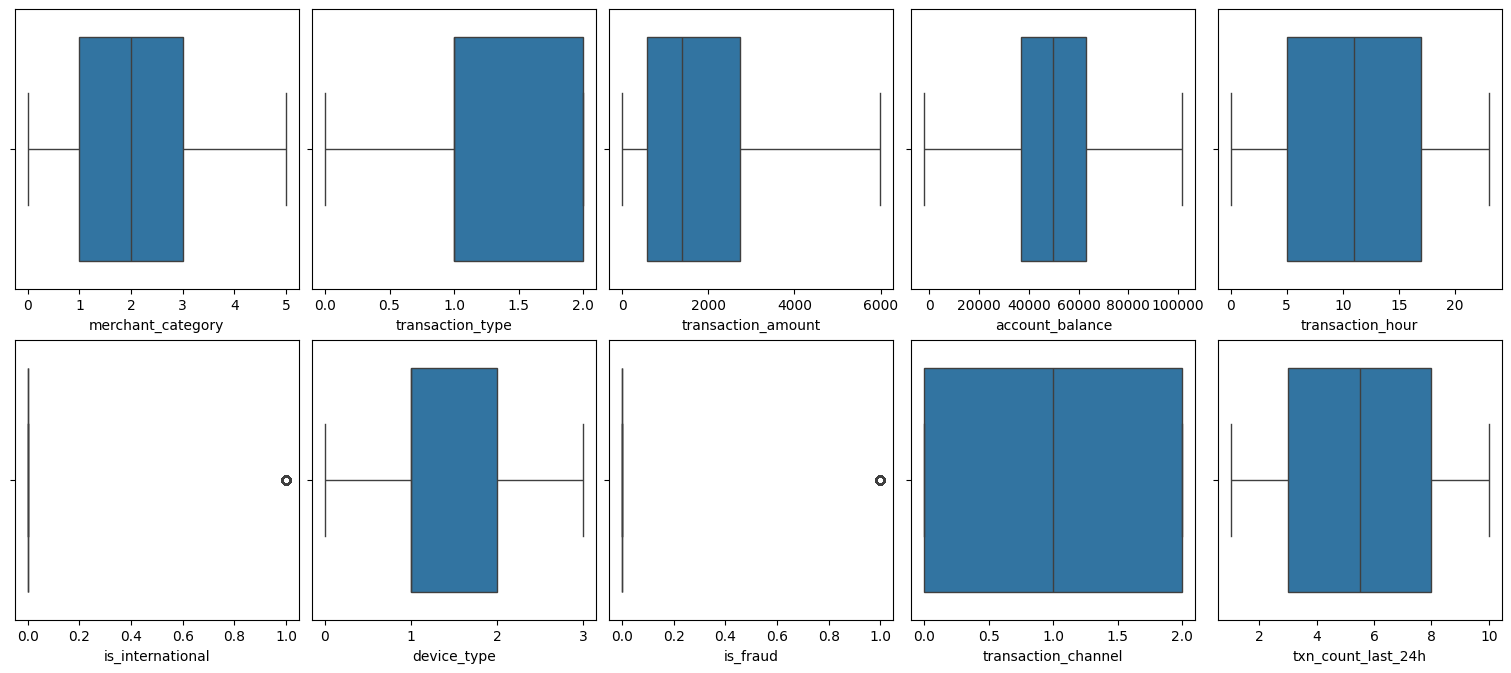

In [25]:
col=['merchant_category', 'transaction_type', 'transaction_amount','account_balance', 'transaction_hour', 'is_international',
          'device_type', 'is_fraud', 'transaction_channel', 'txn_count_last_24h']
plt.figure(figsize=(15,15),layout='constrained')
for i in range(len(col)):
       plt.subplot(5,5,i+1)
       sns.boxplot(data=data,x=col[i])
       plt.savefig('my_graph(1).png')

### Heatmap showing correlation of each feature¶

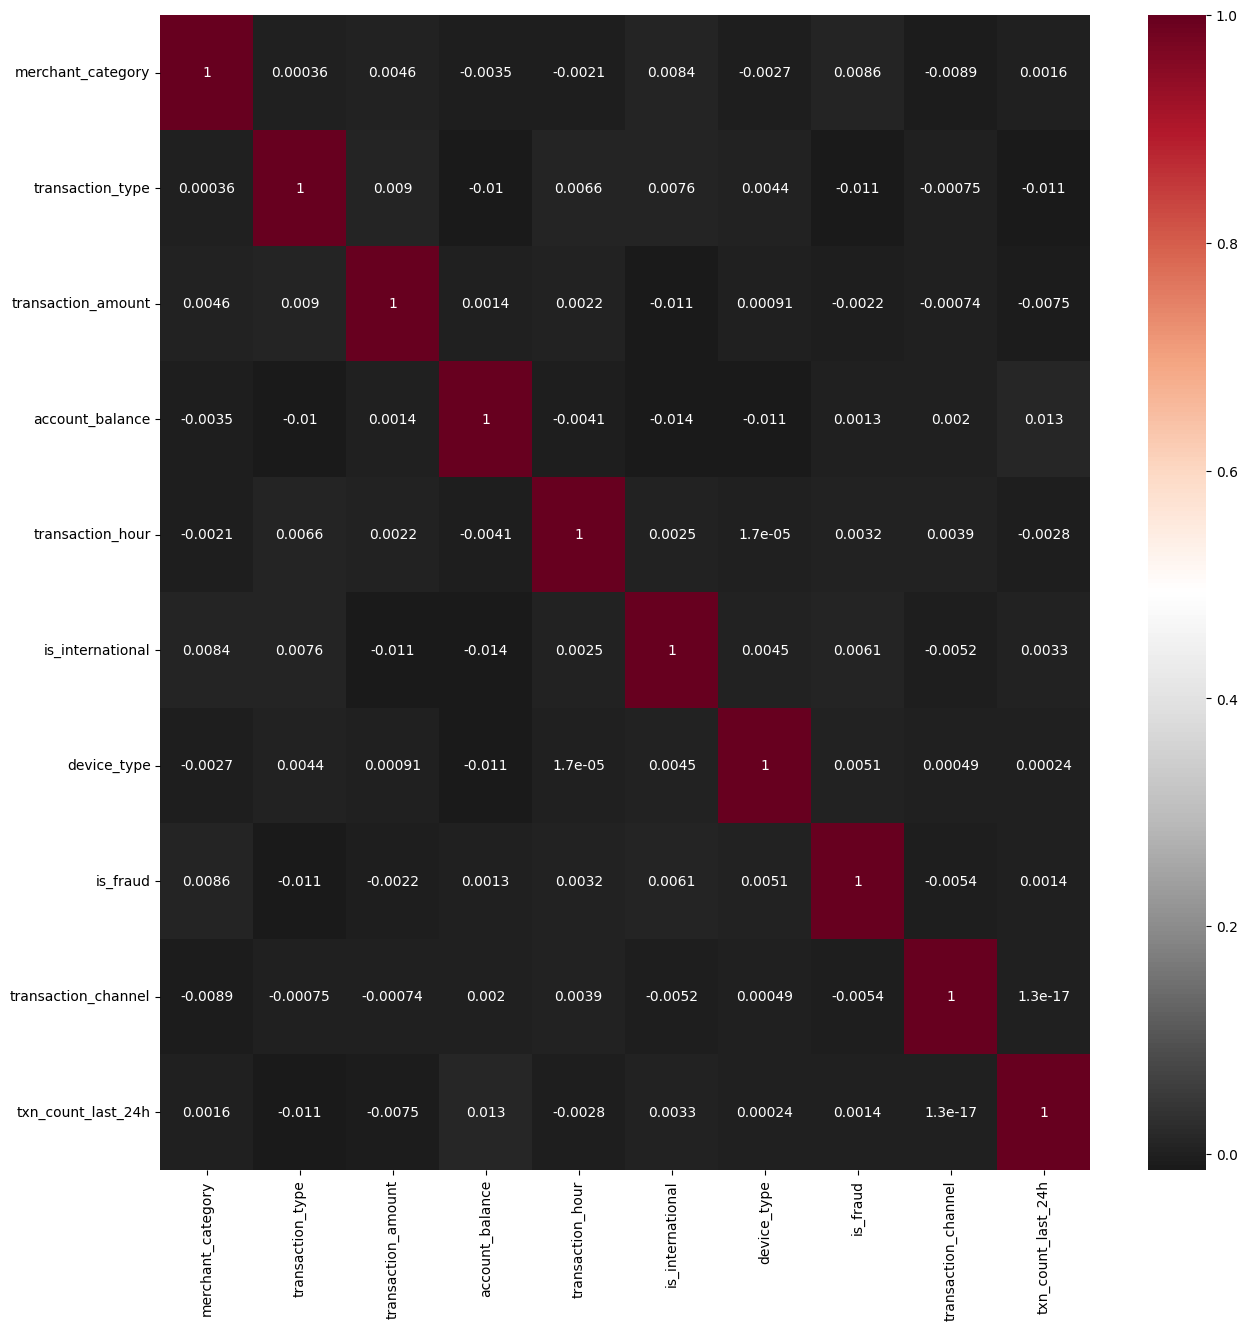

In [26]:
corr = data.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True,cmap='RdGy_r')
plt.show()

### Feature(x)-Target(y) Separation

In [27]:
x = data.drop('is_fraud',axis=1)
y = data['is_fraud']

In [28]:
y

0        0
1        0
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    0
29998    0
29999    0
Name: is_fraud, Length: 30000, dtype: int64

### Feature Scaling

In [29]:
scaling_data = StandardScaler()
x = scaling_data.fit_transform(x)

### Train-Test-Split

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.30,stratify=y,random_state=60)

## Creating Models Before Balancing

### LOGISTIC REGRESSION

Logistic test score: 0.5423333333333333
Logistic train score: 0.5496190476190477

Class report:
              precision    recall  f1-score   support

           0       0.98      0.54      0.70      8812
           1       0.02      0.45      0.04       188

    accuracy                           0.54      9000
   macro avg       0.50      0.50      0.37      9000
weighted avg       0.96      0.54      0.69      9000


Accuracy:
0.5423333333333333


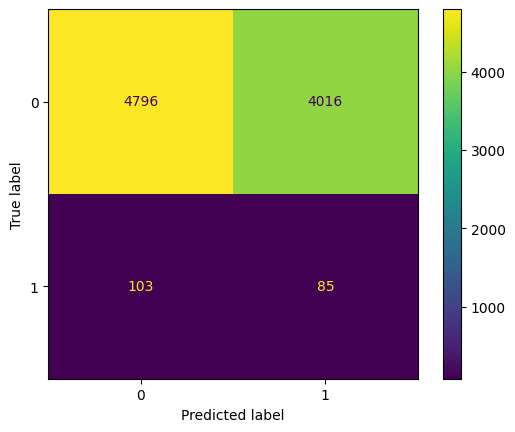

In [31]:
logistics = LogisticRegression(class_weight='balanced', max_iter=1000)
logistics.fit(x_train,y_train)
y_pred_test = logistics.predict(x_test)
y_pred_train = logistics.predict(x_train)
print('Logistic test score:',logistics.score(x_test,y_test))
print('Logistic train score:',logistics.score(x_train,y_train))
print('=================')
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
logistics_score=accuracy_score(y_test,y_pred_test)
print(logistics_score)
print('=================')

### DECISION TREE

DTree test score: 0.3948888888888889
DTree train score: 0.39676190476190476

Class report:
              precision    recall  f1-score   support

           0       0.98      0.39      0.56      8812
           1       0.02      0.64      0.04       188

    accuracy                           0.39      9000
   macro avg       0.50      0.52      0.30      9000
weighted avg       0.96      0.39      0.55      9000


Accuracy:
0.3948888888888889


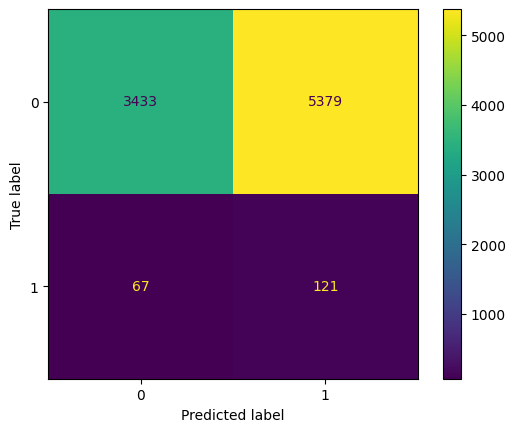

In [32]:
dtree = DecisionTreeClassifier(max_depth=7,class_weight='balanced',random_state=42)
dtree.fit(x_train,y_train)
y_pred_test = dtree.predict(x_test)
y_pred_train = dtree.predict(x_train)
print('DTree test score:',dtree.score(x_test,y_test))
print('DTree train score:',dtree.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
dtree_score=accuracy_score(y_test,y_pred_test)
print(dtree_score)
print('=================')

### RANDOM FOREST

RandomF test score: 0.9791111111111112
RandomF train score: 0.9995714285714286

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8812
           1       0.00      0.00      0.00       188

    accuracy                           0.98      9000
   macro avg       0.49      0.50      0.49      9000
weighted avg       0.96      0.98      0.97      9000


Accuracy:
0.9791111111111112


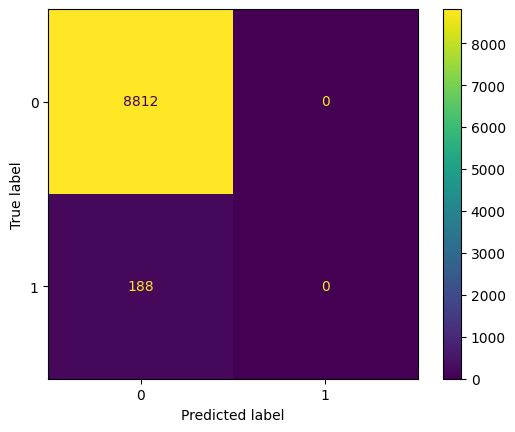

In [33]:
forest = RandomForestClassifier(n_estimators=50,random_state=33)
forest.fit(x_train,y_train)
y_pred_test = forest.predict(x_test)
y_pred_train = forest.predict(x_train)
print('RandomF test score:',forest.score(x_test,y_test))
print('RandomF train score:',forest.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
forest_score=accuracy_score(y_test,y_pred_test)
print(forest_score)
print('=================')

### K NEAREST NEIGHBOR(KNN)

KNN test score: 0.9772222222222222
KNN train score: 0.9792380952380952

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8812
           1       0.00      0.00      0.00       188

    accuracy                           0.98      9000
   macro avg       0.49      0.50      0.49      9000
weighted avg       0.96      0.98      0.97      9000


Accuracy:
0.9772222222222222


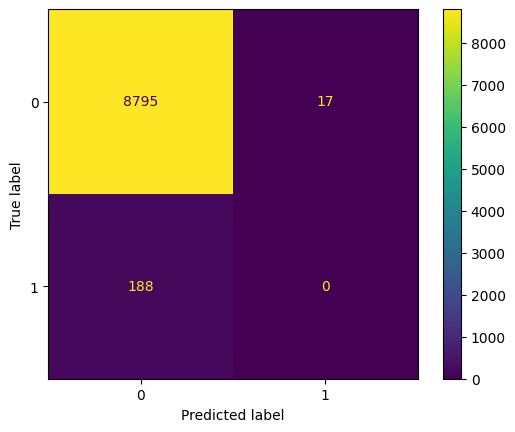

In [34]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred_test = knn.predict(x_test)
y_pred_train = knn.predict(x_train)
print('KNN test score:',knn.score(x_test,y_test))
print('KNN train score:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
knn_score=accuracy_score(y_test,y_pred_test)
print(knn_score)
print('=================')

### SUPPORT VECTOR MACHINE

SVM test score: 0.9791111111111112
SVM train score: 0.979047619047619

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8812
           1       0.00      0.00      0.00       188

    accuracy                           0.98      9000
   macro avg       0.49      0.50      0.49      9000
weighted avg       0.96      0.98      0.97      9000


Accuracy:
0.9791111111111112


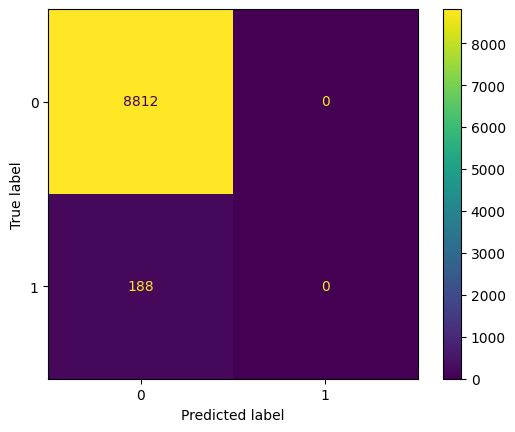

In [35]:
svm = SVC()
svm.fit(x_train,y_train)
y_pred_test = svm.predict(x_test)
y_pred_train = svm.predict(x_train)
print('SVM test score:',svm.score(x_test,y_test))
print('SVM train score:',svm.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
svm_score=accuracy_score(y_test,y_pred_test)
print(svm_score)

### NAIVE BAYES(GaussianNB)

Gaussian test score: 0.9791111111111112
Gaussian train score: 0.979047619047619

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8812
           1       0.00      0.00      0.00       188

    accuracy                           0.98      9000
   macro avg       0.49      0.50      0.49      9000
weighted avg       0.96      0.98      0.97      9000


Accuracy:
0.9791111111111112


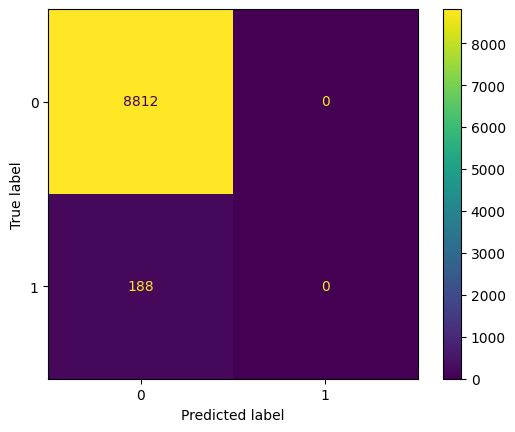

In [36]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)
y_pred_test = gnb.predict(x_test)
y_pred_train = gnb.predict(x_train)
print('Gaussian test score:',gnb.score(x_test,y_test))
print('Gaussian train score:',gnb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
gnb_score=accuracy_score(y_test,y_pred_test)
print(gnb_score)
print('=================')


### ADABOOST

AdaBoost test score: 0.9791111111111112
AdaBoost train score: 0.979047619047619

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8812
           1       0.00      0.00      0.00       188

    accuracy                           0.98      9000
   macro avg       0.49      0.50      0.49      9000
weighted avg       0.96      0.98      0.97      9000


Accuracy:
0.9791111111111112


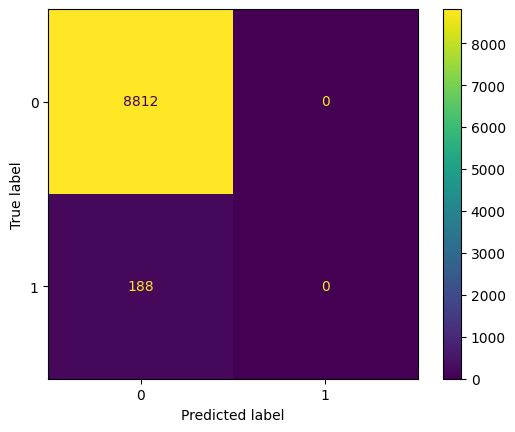

In [37]:
adab = AdaBoostClassifier(n_estimators=50,estimator=None,learning_rate=0.03,random_state=12)
adab.fit(x_train,y_train)
y_pred_test = adab.predict(x_test)
y_pred_train = adab.predict(x_train)
print('AdaBoost test score:',adab.score(x_test,y_test))
print('AdaBoost train score:',adab.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
adab_score=accuracy_score(y_test,y_pred_test)
print(adab_score)
print('=================')

### GRADIENT BOOSTING

Gradient test score: 0.9686666666666667
Gradient train score: 0.9915714285714285

Class report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      8812
           1       0.06      0.03      0.04       188

    accuracy                           0.97      9000
   macro avg       0.52      0.51      0.51      9000
weighted avg       0.96      0.97      0.96      9000


Accuracy:
0.9686666666666667


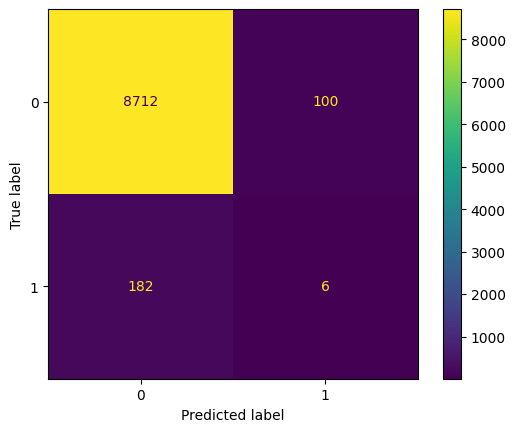

In [38]:
gboost = GradientBoostingClassifier(n_estimators=200,learning_rate=0.2,random_state=42)
gboost.fit(x_train,y_train)
y_pred_test = gboost.predict(x_test)
y_pred_train = gboost.predict(x_train)
print('Gradient test score:',gboost.score(x_test,y_test))
print('Gradient train score:',gboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
gboost_score=accuracy_score(y_test,y_pred_test)
print(gboost_score)
print('=================')

### X-G-BOOST

XGBOOST test score: 0.9788888888888889
XGBOOST train score: 0.9836190476190476

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8812
           1       0.25      0.01      0.01       188

    accuracy                           0.98      9000
   macro avg       0.61      0.50      0.50      9000
weighted avg       0.96      0.98      0.97      9000


Accuracy:
0.9788888888888889


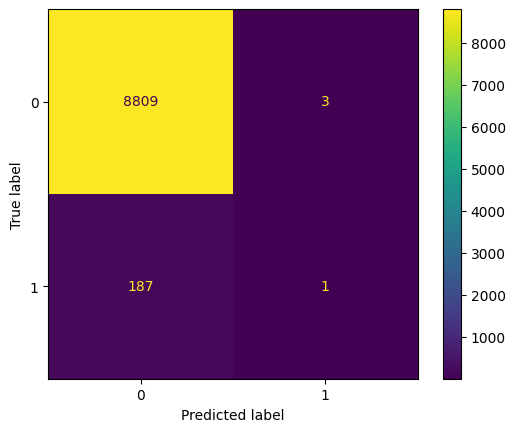

In [39]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)
y_pred_test = xgb.predict(x_test)
y_pred_train = xgb.predict(x_train)
print('XGBOOST test score:',xgb.score(x_test,y_test))
print('XGBOOST train score:',xgb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
xgb_score=accuracy_score(y_test,y_pred_test)
print(xgb_score)
print('=================')

#### Accuracy Score of Models

In [40]:
findings=pd.DataFrame({'model':['logistics','dtree','forest','knn','svm','gnb','adab','gboost','xgb'],
                      'model_accuracy':[logistics_score,dtree_score,forest_score,knn_score,svm_score,gnb_score,adab_score,gboost_score,xgb_score]})
findings

,model,model_accuracy
0,logistics,0.542333
1,dtree,0.394889
2,forest,0.979111
3,knn,0.977222
4,svm,0.979111
5,gnb,0.979111
6,adab,0.979111
7,gboost,0.968667
8,xgb,0.978889


### Balancing Data By Using Over_sampling(SMOTE)

In [41]:
smote = SMOTE(random_state=42)
x_res,y_res = smote.fit_resample(x,y)

print(y.value_counts())       # before sampling
print(y_res.value_counts())

is_fraud
0    29372
1      628
Name: count, dtype: int64
is_fraud
0    29372
1    29372
Name: count, dtype: int64


In [42]:
x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=.30,random_state=60)

## Creating Models After Balancing

### LOGISTIC REGRESSION

Logistic test score: 0.5219019518837948
Logistic train score: 0.5240515564202335

Class report:
              precision    recall  f1-score   support

           0       0.52      0.53      0.52      8806
           1       0.52      0.52      0.52      8818

    accuracy                           0.52     17624
   macro avg       0.52      0.52      0.52     17624
weighted avg       0.52      0.52      0.52     17624


Accuracy:
0.5219019518837948


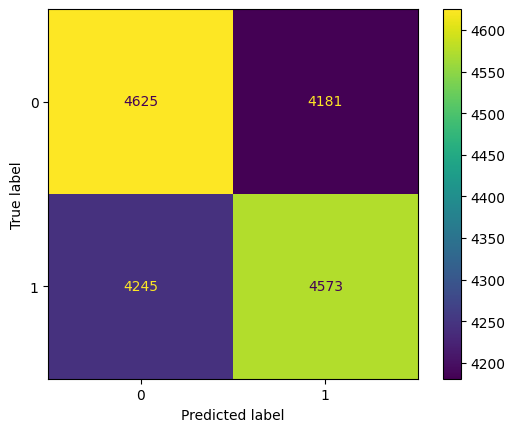

In [43]:
logistics = LogisticRegression(class_weight='balanced', max_iter=1000)
logistics.fit(x_train,y_train)
y_pred_test = logistics.predict(x_test)
y_pred_train = logistics.predict(x_train)

print('Logistic test score:',logistics.score(x_test,y_test))
print('Logistic train score:',logistics.score(x_train,y_train))
print('=================')
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
logistics_score_ov=accuracy_score(y_test,y_pred_test)
print(logistics_score_ov)
print('=================')

### Decision Tree

DTree test score: 0.6702791647753064
DTree train score: 0.6723249027237355

Class report:
              precision    recall  f1-score   support

           0       0.88      0.39      0.54      8806
           1       0.61      0.95      0.74      8818

    accuracy                           0.67     17624
   macro avg       0.74      0.67      0.64     17624
weighted avg       0.74      0.67      0.64     17624


Accuracy:
0.6702791647753064


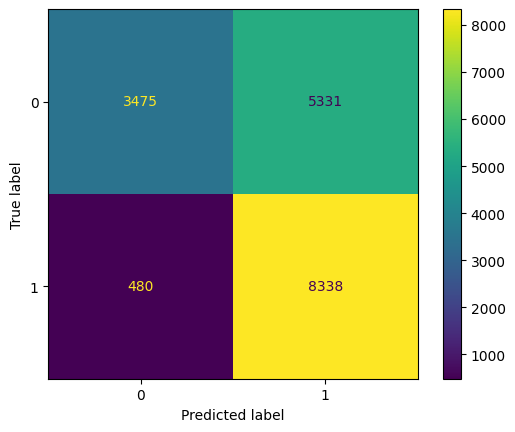

In [44]:
dtree = DecisionTreeClassifier(max_depth=7)
dtree.fit(x_train,y_train)
y_pred_test = dtree.predict(x_test)
y_pred_train = dtree.predict(x_train)
print('DTree test score:',dtree.score(x_test,y_test))
print('DTree train score:',dtree.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
dtree_score_ov=accuracy_score(y_test,y_pred_test)
print(dtree_score_ov)

### Random Forest

RandomF test score: 0.9884248751702224
RandomF train score: 0.9999756809338521

Class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8806
           1       1.00      0.98      0.99      8818

    accuracy                           0.99     17624
   macro avg       0.99      0.99      0.99     17624
weighted avg       0.99      0.99      0.99     17624


Accuracy:
0.9884248751702224


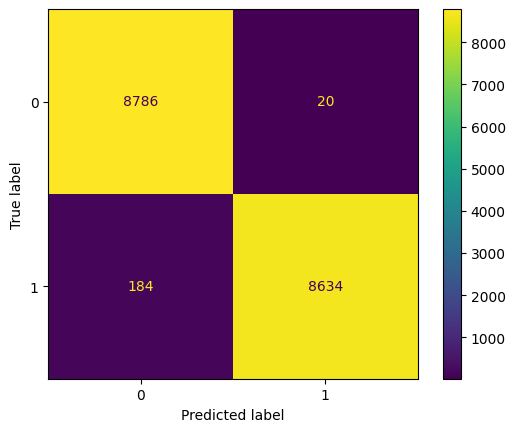

In [45]:
forest = RandomForestClassifier(n_estimators=50,random_state=33)
forest.fit(x_train,y_train)
y_pred_test = forest.predict(x_test)
y_pred_train = forest.predict(x_train)
print('RandomF test score:',forest.score(x_test,y_test))
print('RandomF train score:',forest.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
forest_score_ov=accuracy_score(y_test,y_pred_test)
print(forest_score_ov)

### K NEAREST NEIGHBORS(KNN)

KNN test score: 0.9383794825238312
KNN train score: 0.9667801556420234

Class report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93      8806
           1       0.89      1.00      0.94      8818

    accuracy                           0.94     17624
   macro avg       0.94      0.94      0.94     17624
weighted avg       0.94      0.94      0.94     17624


Accuracy:
0.9383794825238312


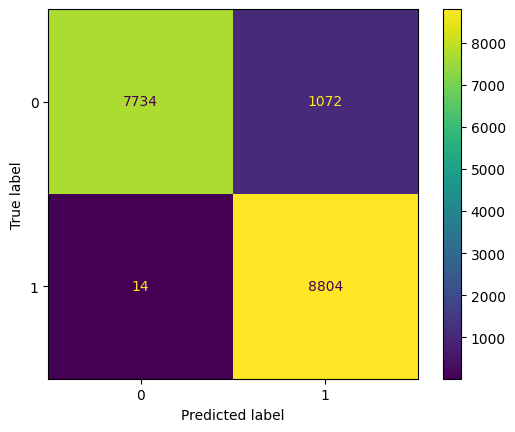

In [46]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred_test = knn.predict(x_test)
y_pred_train = knn.predict(x_train)
print('KNN test score:',knn.score(x_test,y_test))
print('KNN train score:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
knn_score_ov=accuracy_score(y_test,y_pred_test)
print(knn_score_ov)

### SUPPORT VECTOR MACHINE

SVM test score: 0.5222991375397186
SVM train score: 0.5241245136186771

Class report:
              precision    recall  f1-score   support

           0       0.52      0.53      0.52      8806
           1       0.52      0.52      0.52      8818

    accuracy                           0.52     17624
   macro avg       0.52      0.52      0.52     17624
weighted avg       0.52      0.52      0.52     17624


Accuracy:
0.5222991375397186


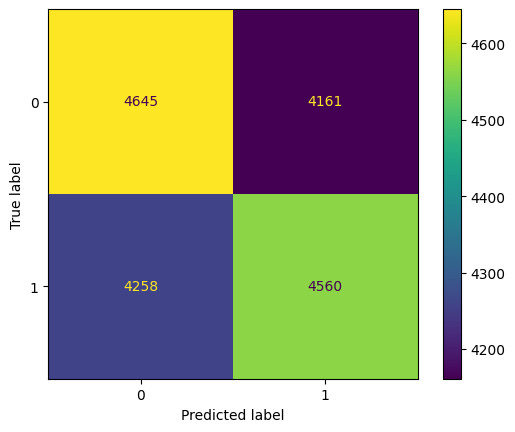

In [47]:
from sklearn.svm import LinearSVC
svm = LinearSVC()
svm.fit(x_train,y_train)
y_pred_test = svm.predict(x_test)
y_pred_train = svm.predict(x_train)
print('SVM test score:',svm.score(x_test,y_test))
print('SVM train score:',svm.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
svm_score_ov=accuracy_score(y_test,y_pred_test)
print(svm_score_ov)

### NAIVE BAYES(GaussianNB)

Gaussian test score: 0.5653654108034498
Gaussian train score: 0.570136186770428

Class report:
              precision    recall  f1-score   support

           0       0.57      0.55      0.56      8806
           1       0.56      0.58      0.57      8818

    accuracy                           0.57     17624
   macro avg       0.57      0.57      0.57     17624
weighted avg       0.57      0.57      0.57     17624


Accuracy:
0.5653654108034498


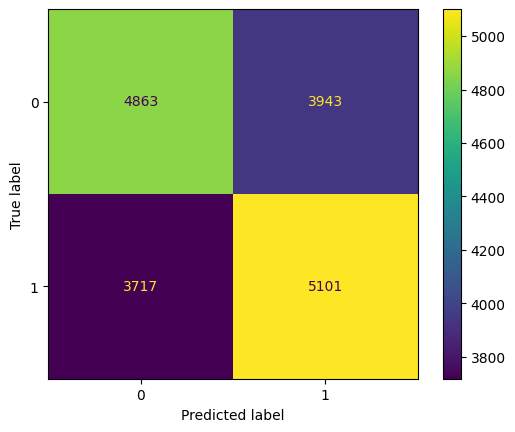

In [48]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)
y_pred_test = gnb.predict(x_test)
y_pred_train = gnb.predict(x_train)
print('Gaussian test score:',gnb.score(x_test,y_test))
print('Gaussian train score:',gnb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
gnb_score_ov=accuracy_score(y_test,y_pred_test)
print(gnb_score_ov)

### ADABOOST

AdaBoost test score: 0.5448819791193826
AdaBoost train score: 0.5423151750972762

Class report:
              precision    recall  f1-score   support

           0       0.80      0.12      0.21      8806
           1       0.52      0.97      0.68      8818

    accuracy                           0.54     17624
   macro avg       0.66      0.54      0.44     17624
weighted avg       0.66      0.54      0.44     17624


Accuracy:
0.5448819791193826


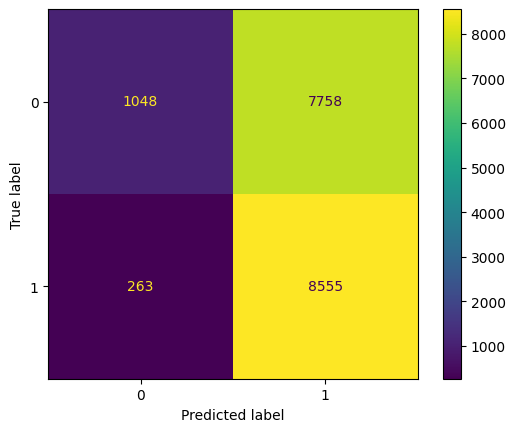

In [49]:
adab = AdaBoostClassifier(n_estimators=50,estimator=None,learning_rate=0.03,random_state=12)
adab.fit(x_train,y_train)
y_pred_test = adab.predict(x_test)
y_pred_train = adab.predict(x_train)
print('AdaBoost test score:',adab.score(x_test,y_test))
print('AdaBoost train score:',adab.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
adab_score_ov=accuracy_score(y_test,y_pred_test)
print(adab_score_ov)

### GRADIENT BOOSTING

Gradient test score: 0.9841693145710395
Gradient train score: 0.9855787937743191

Class report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      8806
           1       1.00      0.97      0.98      8818

    accuracy                           0.98     17624
   macro avg       0.98      0.98      0.98     17624
weighted avg       0.98      0.98      0.98     17624


Accuracy:
0.9841693145710395


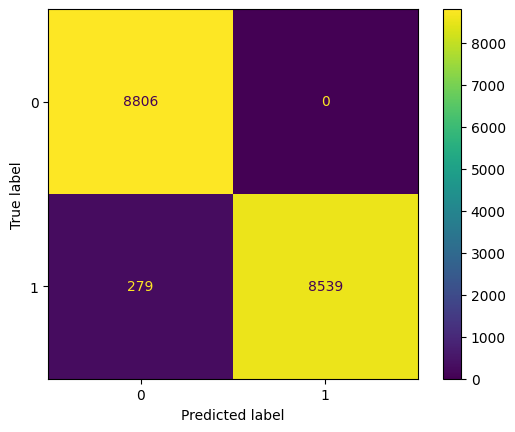

In [50]:
gboost = GradientBoostingClassifier(n_estimators=200,learning_rate=0.2,random_state=42)
gboost.fit(x_train,y_train)
y_pred_test = gboost.predict(x_test)
y_pred_train = gboost.predict(x_train)
print('Gradient test score:',gboost.score(x_test,y_test))
print('Gradient train score:',gboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
gboost_score_ov=accuracy_score(y_test,y_pred_test)
print(gboost_score_ov)

### X-G BOOST

XGBOOST test score: 0.9851906491148434
XGBOOST train score: 0.9883511673151751

Class report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      8806
           1       1.00      0.97      0.98      8818

    accuracy                           0.99     17624
   macro avg       0.99      0.99      0.99     17624
weighted avg       0.99      0.99      0.99     17624


Accuracy:
0.9851906491148434


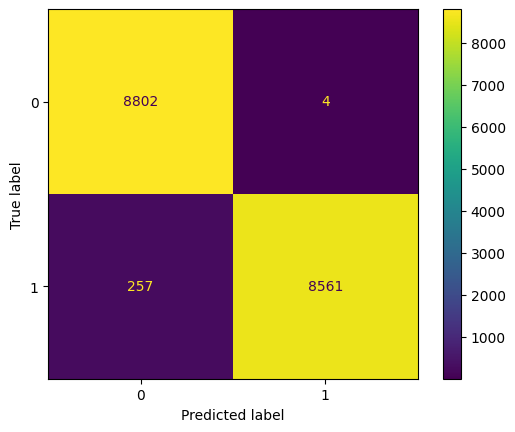

In [51]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)
y_pred_test = xgb.predict(x_test)
y_pred_train = xgb.predict(x_train)
print('XGBOOST test score:',xgb.score(x_test,y_test))
print('XGBOOST train score:',xgb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))
print('\nClass report:')
print('=================')
print(classification_report(y_test,y_pred_test))
print('\nAccuracy:')
print('=================')
xgb_score_ov=accuracy_score(y_test,y_pred_test)
print(xgb_score_ov)

In [52]:
findings=pd.DataFrame({'model':['logistics','dtree','forest','knn','svm','gnb','adab','gboost','xgb'],
                      'model_accuracy_bofore_ov':[logistics_score,dtree_score,forest_score,knn_score,svm_score,gnb_score,adab_score,gboost_score,xgb_score],
                      'model_accuracy_after_ov':[logistics_score_ov,dtree_score_ov,forest_score_ov,knn_score_ov,svm_score_ov,gnb_score_ov,adab_score_ov,gboost_score_ov,xgb_score_ov]})
findings

,model,model_accuracy_bofore_ov,model_accuracy_after_ov
0,logistics,0.542333,0.521902
1,dtree,0.394889,0.670279
2,forest,0.979111,0.988425
3,knn,0.977222,0.938379
4,svm,0.979111,0.522299
5,gnb,0.979111,0.565365
6,adab,0.979111,0.544882
7,gboost,0.968667,0.984169
8,xgb,0.978889,0.985191


### Hyperparameter Tuning for the Top 5 Models

In [53]:
model_params = {'Random_Forest':{'model':RandomForestClassifier(random_state=42,class_weight='balanced'),'params':{'n_estimators':[200,300],'max_depth': [15,20],'min_samples_split': [5, 10],'max_features': ['sqrt', 'log2'],'min_samples_leaf': [ 2, 4]}},
                'XGBoost':{'model':XGBClassifier(),'params':{'n_estimators': [50,100],'learning_rate': [0.05, 0.03]}},
                'Gradient_Boosting':{'model':GradientBoostingClassifier(),'params':{'n_estimators':[100,200],'learning_rate': [0.01, 0.05, 0.1],'max_features':['sqrt', 'log2']}},
                'KNN':{'model':KNeighborsClassifier(),'params':{'n_neighbors': [3, 5, 7, 9],'weights': ['uniform', 'distance']}},
                'Decision_Tree':{'model':DecisionTreeClassifier(),'params':{'max_depth':[5,7],'criterion':['gini','entropy'],}}}

In [54]:
scores=[]
models = ['Random_Forest','XGBoost','Gradient_Boosting','KNN','Decision_Tree']
for model_name in models:
    mp=model_params[model_name]
    gscv=GridSearchCV(mp['model'],mp['params'],cv=5,scoring='recall',n_jobs=-1,verbose=2)
    gscv.fit(x_train,y_train)
    scores.append({'model':model_name,'best_score':gscv.best_score_,'best_params':gscv.best_params_,'best_model': gscv.best_estimator_})

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [55]:
results = pd.DataFrame(scores)
results

,model,best_score,best_params,best_model
0,Random_Forest,0.970322,"{'max_depth': 20, 'max_features': 'sqrt', 'min...","(DecisionTreeClassifier(max_depth=20, max_feat..."
1,XGBoost,0.912523,"{'learning_rate': 0.05, 'n_estimators': 100}","XGBClassifier(base_score=None, booster=None, c..."
2,Gradient_Boosting,0.929260,"{'learning_rate': 0.1, 'max_features': 'sqrt',...",([DecisionTreeRegressor(criterion='friedman_ms...
3,KNN,0.999465,"{'n_neighbors': 9, 'weights': 'distance'}","KNeighborsClassifier(n_neighbors=9, weights='d..."
4,Decision_Tree,0.945315,"{'criterion': 'gini', 'max_depth': 7}",DecisionTreeClassifier(max_depth=7)


### Access The Best Model

In [56]:
best_row = results[results['model'] == 'Random_Forest'].iloc[0]  # Here we select second best model 'Random_Forest' instead of 'knn' because it will fail to generalize in real-world inputs especialy with an highly imbalanced dataset.
best_model = best_row['best_model']

In [57]:
best_model

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

Train Accuracy: 0.987329766536965
Test Accuracy: 0.9799137539718565
Model Accuracy: 0.9799137539718565
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8806
           1       0.99      0.97      0.98      8818

    accuracy                           0.98     17624
   macro avg       0.98      0.98      0.98     17624
weighted avg       0.98      0.98      0.98     17624



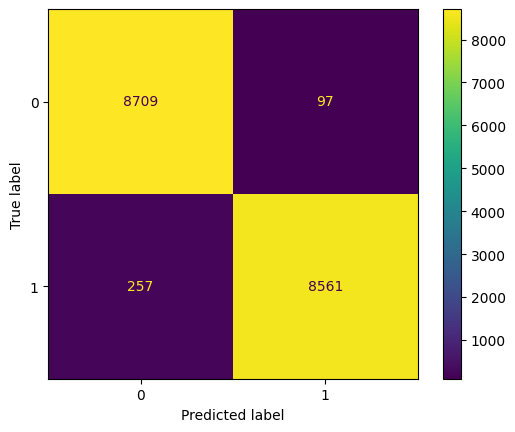

In [59]:
train_accuracy = best_model.score(x_train,y_train)
test_accuracy = best_model.score(x_test,y_test)
y_pred = best_model.predict(x_test)
print('Train Accuracy:',train_accuracy)
print('====================================')
print('Test Accuracy:',test_accuracy)
print('====================================')
print('Model Accuracy:',accuracy_score(y_test,y_pred))
print('====================================')
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print(classification_report(y_test,y_pred))

### Save Model

In [60]:
import joblib
#save best_model
joblib.dump(best_model,'best_model_RFC.pkl', compress=3)

# Save StandardScaler
joblib.dump(scaling_data,'scaler_RFC.pkl')

# save all label encoders together
label_encoder = {'merchant_category':le1,'transaction_type':le2,'device_type':le3,'transaction_channel':le4}
joblib.dump(label_encoder, 'label_encoder_RFC.pkl')


['label_encoder_RFC.pkl']